In [ ]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string # special operations on stringsa
import spacy

from matplotlib.pyplot import imread
from matplotlib import pyplot as plt
from wordcloud import WordCloud
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
hotel_data = pd.read_excel('Hotel_Reviews.xlsx')

In [ ]:
hotel_data

,Review,Feedback
0,nice hotel expensive parking got good deal sta...,Pos
1,ok nothing special charge diamond member hilto...,Neg
2,nice rooms not 4* experience hotel monaco seat...,Pos
3,"unique, great stay, wonderful time hotel monac...",Pos
4,"great stay great stay, went seahawk game aweso...",Pos
...,...,...
20486,"best kept secret 3rd time staying charm, not 5...",Pos
20487,great location price view hotel great quick pl...,Pos
20488,"ok just looks nice modern outside, desk staff ...",Neg
20489,hotel theft ruined vacation hotel opened sept ...,Neg


In [ ]:
hotel_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Review    20491 non-null  object
 1   Feedback  20491 non-null  object
dtypes: object(2)
memory usage: 320.3+ KB


In [ ]:
# checking for missing data
hotel_data.isna().sum()

Review      0
Feedback    0
dtype: int64

In [ ]:
# checking for any duplicate values
hotel_data.duplicated().sum()

0

In [ ]:
# shape of the dataset
hotel_data.shape

(20491, 2)

In [ ]:
# checking target variable
hotel_data['Feedback'].value_counts()

Feedback
Pos    17277
Neg     3214
Name: count, dtype: int64

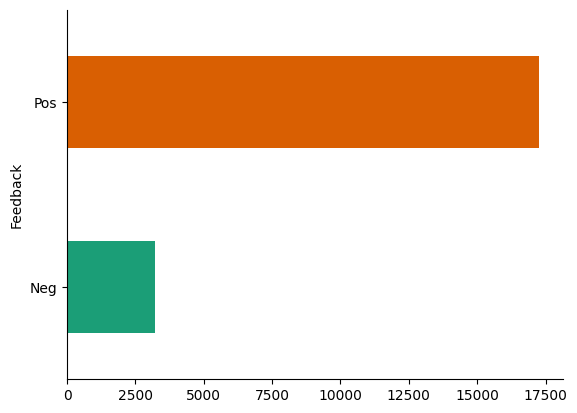

In [ ]:
# @title Feedback

from matplotlib import pyplot as plt
import seaborn as sns
hotel_data.groupby('Feedback').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

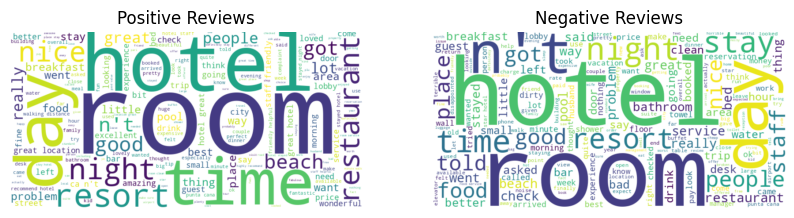

In [ ]:
# @title Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Separate reviews by sentiment
pos_reviews = hotel_data[hotel_data['Feedback'] == 'Pos']['Review']
neg_reviews = hotel_data[hotel_data['Feedback'] == 'Neg']['Review']

# Combine all reviews for each sentiment
pos_text = ' '.join(pos_reviews)
neg_text = ' '.join(neg_reviews)

# Generate word clouds
pos_wc = WordCloud(width=800, height=400, background_color='white').generate(pos_text)
neg_wc = WordCloud(width=800, height=400, background_color='white').generate(neg_text)

# Plot word clouds
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(pos_wc, interpolation='bilinear')
plt.title('Positive Reviews')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(neg_wc, interpolation='bilinear')
plt.title('Negative Reviews')
plt.axis('off')

plt.show()


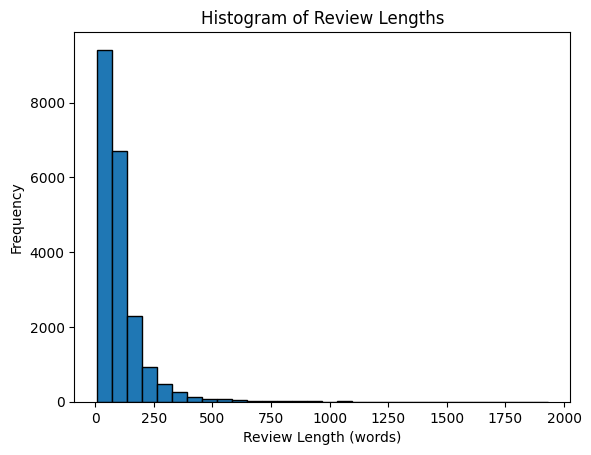

In [ ]:
# @title Review Length
# Calculate review length
hotel_data['Review Length'] = hotel_data['Review'].apply(lambda x: len(x.split()))

plt.hist(hotel_data['Review Length'], bins=30, edgecolor='k')
plt.xlabel('Review Length (words)')
plt.ylabel('Frequency')
plt.title('Histogram of Review Lengths')
plt.show()


In [ ]:
hotel_data['Review']

0        nice hotel expensive parking got good deal sta...
1        ok nothing special charge diamond member hilto...
2        nice rooms not 4* experience hotel monaco seat...
3        unique, great stay, wonderful time hotel monac...
4        great stay great stay, went seahawk game aweso...
                               ...                        
20486    best kept secret 3rd time staying charm, not 5...
20487    great location price view hotel great quick pl...
20488    ok just looks nice modern outside, desk staff ...
20489    hotel theft ruined vacation hotel opened sept ...
20490    people talking, ca n't believe excellent ratin...
Name: Review, Length: 20491, dtype: object

In [ ]:
df_pos = hotel_data[hotel_data['Feedback'] == 'Pos'].reset_index(drop=True)
df_neg = hotel_data[hotel_data['Feedback'] == 'Neg'].reset_index(drop=True)

In [ ]:
df_pos

,Review,Feedback,Review Length
0,nice hotel expensive parking got good deal sta...,Pos,87
1,nice rooms not 4* experience hotel monaco seat...,Pos,217
2,"unique, great stay, wonderful time hotel monac...",Pos,89
3,"great stay great stay, went seahawk game aweso...",Pos,191
4,love monaco staff husband stayed hotel crazy w...,Pos,134
...,...,...,...
17272,great play stay stay loyal inn package deal ha...,Pos,33
17273,great choice wife chose best western quite bit...,Pos,105
17274,good bed clean convenient just night happy sta...,Pos,61
17275,"best kept secret 3rd time staying charm, not 5...",Pos,109


In [ ]:
df_neg

,Review,Feedback,Review Length
0,ok nothing special charge diamond member hilto...,Neg,250
1,"poor value stayed monaco seattle july, nice ho...",Neg,47
2,horrible customer service hotel stay february ...,Neg,214
3,disappointed say anticipating stay hotel monac...,Neg,242
4,great location need internally upgrade advanta...,Neg,35
...,...,...,...
3209,deceptive staff deceptive desk staff claiming ...,Neg,102
3210,not impressed unfriendly staff checked asked h...,Neg,87
3211,"ok just looks nice modern outside, desk staff ...",Neg,63
3212,hotel theft ruined vacation hotel opened sept ...,Neg,781


In [ ]:
hotel_data

,Review,Feedback,Review Length
0,nice hotel expensive parking got good deal sta...,Pos,87
1,ok nothing special charge diamond member hilto...,Neg,250
2,nice rooms not 4* experience hotel monaco seat...,Pos,217
3,"unique, great stay, wonderful time hotel monac...",Pos,89
4,"great stay great stay, went seahawk game aweso...",Pos,191
...,...,...,...
20486,"best kept secret 3rd time staying charm, not 5...",Pos,109
20487,great location price view hotel great quick pl...,Pos,39
20488,"ok just looks nice modern outside, desk staff ...",Neg,63
20489,hotel theft ruined vacation hotel opened sept ...,Neg,781


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
def clean_text(text):
    '''Make text lowercase, remove text in square brackets, remove punctuation and remove words containing numbers.'''
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = re.sub("[0-9" "]+"," ",text)
    text = re.sub('[‘’“”…]', '', text)
    return text

clean = lambda x: clean_text(x)

In [ ]:
hotel_data['Review'] = hotel_data.Review.apply(clean)
hotel_data.Review

0        nice hotel expensive parking got good deal sta...
1        ok nothing special charge diamond member hilto...
2        nice rooms not  experience hotel monaco seattl...
3        unique great stay wonderful time hotel monaco ...
4        great stay great stay went seahawk game awesom...
                               ...                        
20486    best kept secret  time staying charm not  ca n...
20487    great location price view hotel great quick pl...
20488    ok just looks nice modern outside desk staff n...
20489    hotel theft ruined vacation hotel opened sept ...
20490    people talking ca nt believe excellent ratings...
Name: Review, Length: 20491, dtype: object

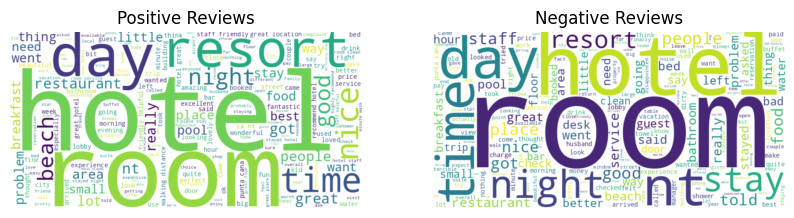

In [ ]:

# @title Word Cloud after cleaning the data
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Separate reviews by sentiment
pos_reviews = hotel_data[hotel_data['Feedback'] == 'Pos']['Review']
neg_reviews = hotel_data[hotel_data['Feedback'] == 'Neg']['Review']

# Combine all reviews for each sentiment
pos_text = ' '.join(pos_reviews)
neg_text = ' '.join(neg_reviews)

# Generate word clouds
pos_wc = WordCloud(width=800, height=400, background_color='white').generate(pos_text)
neg_wc = WordCloud(width=800, height=400, background_color='white').generate(neg_text)

# Plot word clouds
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(pos_wc, interpolation='bilinear')
plt.title('Positive Reviews')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(neg_wc, interpolation='bilinear')
plt.title('Negative Reviews')
plt.axis('off')

plt.show()


In [ ]:
Reviews = [text.strip() for text in hotel_data.Review] # remove both the leading and the trailing characters


In [ ]:
len(Reviews)

20491

In [ ]:
Reviews = [text for text in Reviews if text] # removes empty strings, because they are considered in Python as False


In [ ]:
len(Reviews)

20491

In [ ]:
# Joining the list into one string/text
Reviews_text = ' '.join(Reviews)
len(Reviews_text)

14322906

In [ ]:
print(Reviews_text[0:500])

nice hotel expensive parking got good deal stay hotel anniversary arrived late evening took advice previous reviews did valet parking check quick easy little disappointed nonexistent view room room clean nice size bed comfortable woke stiff neck high pillows not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway maybe just noisy neighbors aveda bath products nice did not goldfish stay nice touch taken advantage staying longer location grea


In [ ]:
# @title RUN THIS IF YOU GET ERROR IN THE BELOW CODE

# import nltk
# nltk.download('punkt')




[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# Tokenization
from nltk.tokenize import word_tokenize
Reviews_tokens = word_tokenize(Reviews_text)
print(Reviews_tokens[0:500])

['nice', 'hotel', 'expensive', 'parking', 'got', 'good', 'deal', 'stay', 'hotel', 'anniversary', 'arrived', 'late', 'evening', 'took', 'advice', 'previous', 'reviews', 'did', 'valet', 'parking', 'check', 'quick', 'easy', 'little', 'disappointed', 'nonexistent', 'view', 'room', 'room', 'clean', 'nice', 'size', 'bed', 'comfortable', 'woke', 'stiff', 'neck', 'high', 'pillows', 'not', 'soundproof', 'like', 'heard', 'music', 'room', 'night', 'morning', 'loud', 'bangs', 'doors', 'opening', 'closing', 'hear', 'people', 'talking', 'hallway', 'maybe', 'just', 'noisy', 'neighbors', 'aveda', 'bath', 'products', 'nice', 'did', 'not', 'goldfish', 'stay', 'nice', 'touch', 'taken', 'advantage', 'staying', 'longer', 'location', 'great', 'walking', 'distance', 'shopping', 'overall', 'nice', 'experience', 'having', 'pay', 'parking', 'night', 'ok', 'nothing', 'special', 'charge', 'diamond', 'member', 'hilton', 'decided', 'chain', 'shot', 'anniversary', 'seattle', 'start', 'booked', 'suite', 'paid', 'extr

In [ ]:
len(Reviews_tokens)

2077073

In [ ]:
# Stopwords
# Remove Stopwords
import nltk
from nltk.corpus import stopwords
my_stop_words = stopwords.words('english')
my_stop_words.append('the')
no_stop_tokens = [word for word in Reviews_tokens if not word in my_stop_words]
print(no_stop_tokens[0:100])

['nice', 'hotel', 'expensive', 'parking', 'got', 'good', 'deal', 'stay', 'hotel', 'anniversary', 'arrived', 'late', 'evening', 'took', 'advice', 'previous', 'reviews', 'valet', 'parking', 'check', 'quick', 'easy', 'little', 'disappointed', 'nonexistent', 'view', 'room', 'room', 'clean', 'nice', 'size', 'bed', 'comfortable', 'woke', 'stiff', 'neck', 'high', 'pillows', 'soundproof', 'like', 'heard', 'music', 'room', 'night', 'morning', 'loud', 'bangs', 'doors', 'opening', 'closing', 'hear', 'people', 'talking', 'hallway', 'maybe', 'noisy', 'neighbors', 'aveda', 'bath', 'products', 'nice', 'goldfish', 'stay', 'nice', 'touch', 'taken', 'advantage', 'staying', 'longer', 'location', 'great', 'walking', 'distance', 'shopping', 'overall', 'nice', 'experience', 'pay', 'parking', 'night', 'ok', 'nothing', 'special', 'charge', 'diamond', 'member', 'hilton', 'decided', 'chain', 'shot', 'anniversary', 'seattle', 'start', 'booked', 'suite', 'paid', 'extra', 'website', 'description', 'suite']


In [ ]:
len(no_stop_tokens)

2001326

In [ ]:
# Noramalize the data
lower_words = [text.lower() for text in no_stop_tokens]
print(lower_words[0:50])

['nice', 'hotel', 'expensive', 'parking', 'got', 'good', 'deal', 'stay', 'hotel', 'anniversary', 'arrived', 'late', 'evening', 'took', 'advice', 'previous', 'reviews', 'valet', 'parking', 'check', 'quick', 'easy', 'little', 'disappointed', 'nonexistent', 'view', 'room', 'room', 'clean', 'nice', 'size', 'bed', 'comfortable', 'woke', 'stiff', 'neck', 'high', 'pillows', 'soundproof', 'like', 'heard', 'music', 'room', 'night', 'morning', 'loud', 'bangs', 'doors', 'opening', 'closing']


In [ ]:
# NLP english language model of spacy library
nlp = spacy.load("en_core_web_sm")

In [ ]:
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# 'lower_words' is a list of tokenized words from a lowercased text
lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(word) for word in lower_words]

# Join the lemmatized tokens back into a string
final_text = ' '.join(lemmatized_tokens)

# Vectorization (using TF-IDF)
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([final_text])


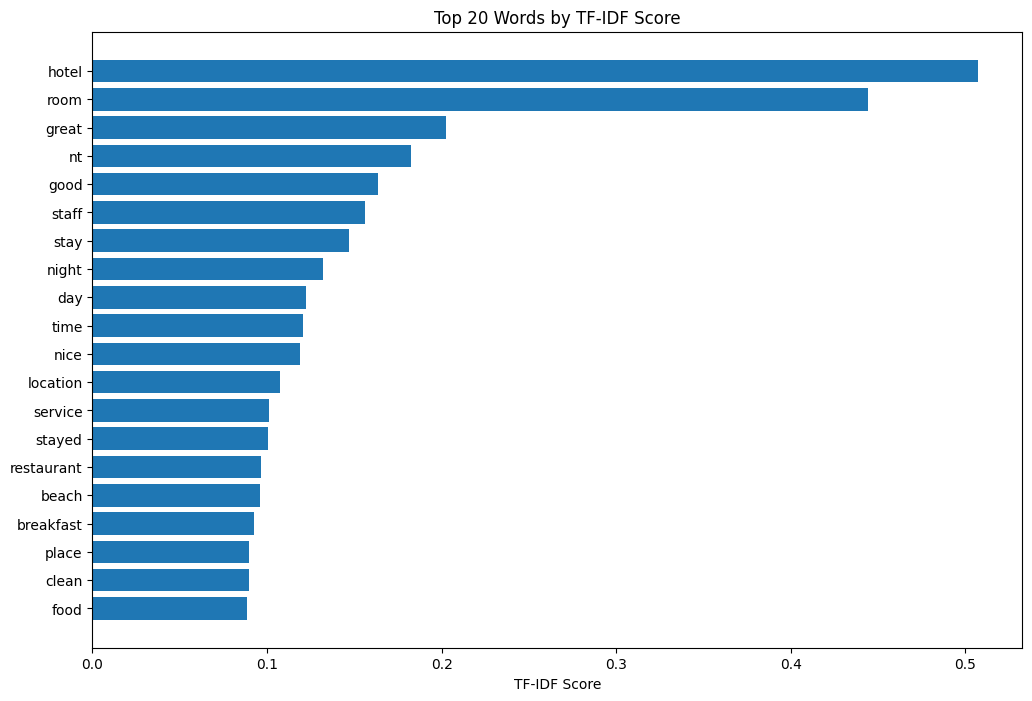

In [ ]:
import numpy as np

# Get feature names and their TF-IDF scores
feature_names = vectorizer.get_feature_names_out()
scores = np.asarray(X.mean(axis=0)).flatten()

# Create DataFrame
top_words = pd.DataFrame({'Word': feature_names, 'TF-IDF Score': scores})
top_words = top_words.sort_values(by='TF-IDF Score', ascending=False).head(20)

# Plot bar chart
plt.figure(figsize=(12, 8))
plt.barh(top_words['Word'], top_words['TF-IDF Score'])
plt.xlabel('TF-IDF Score')
plt.title('Top 20 Words by TF-IDF Score')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
X.shape

(1, 71355)

In [ ]:
hotel_data.shape

(20491, 3)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import RandomOverSampler


In [ ]:
!pip install sentence-transformers

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [ ]:
import pandas as pd
import re
import string
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from imblearn.over_sampling import RandomOverSampler
import numpy as np

# Load Sentence Transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Define the text cleaning function
def clean_text(text):
    '''Make text lowercase, remove text in square brackets, remove punctuation and remove words containing numbers.'''
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = re.sub("[0-9]+", " ", text)
    text = re.sub('[''""…]', '', text)
    return text

# Load dataset
df = pd.read_excel('Hotel_Reviews.xlsx')

# Apply text cleaning
df['Review'] = df['Review'].apply(clean_text)

# Get embeddings
df['Embeddings'] = df['Review'].apply(lambda x: model.encode(x))




In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Split the dataset
X = list(df['Embeddings'])
y = df['Feedback']
# Handle imbalance using RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Define models and their parameters for tuning
models = {
    'SVM': (SVC(), {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}),
    'Random Forest': (RandomForestClassifier(), {'n_estimators': [50, 100], 'max_depth': [None, 10]}),
    'Logistic Regression': (LogisticRegression(), {'C': [0.1, 1, 10]})
}

# Function to train and evaluate a model
def train_evaluate_model(model, params, X_train, X_test, y_train, y_test):
    random_search = RandomizedSearchCV(model, params, n_iter=5, cv=3, scoring='f1', n_jobs=-1, random_state=42)
    random_search.fit(X_train, y_train)
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    return best_model, accuracy, f1, random_search.best_params_

# Train and evaluate all models
results = []
for name, (model, params) in models.items():
    print(f"Training {name}...")
    best_model, accuracy, f1, best_params = train_evaluate_model(model, params, X_train, X_test, y_train, y_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1 Score': f1,
        'Best Parameters': best_params
    })
    print(f"{name} completed.")




Training SVM...
SVM completed.
Training Random Forest...
Random Forest completed.
Training Logistic Regression...
Logistic Regression completed.
                 Model  Accuracy  F1 Score  \
0                  SVM  0.904500  0.904497   
1        Random Forest  0.978151  0.978149   
2  Logistic Regression  0.892635  0.892637   

                           Best Parameters  
0              {'kernel': 'rbf', 'C': 0.1}  
1  {'n_estimators': 50, 'max_depth': None}  
2                               {'C': 0.1}  

Best Model: Random Forest

Classification Report for Best Model:
              precision    recall  f1-score   support

         Neg       0.96      0.99      0.98      3419
         Pos       0.99      0.96      0.98      3492

    accuracy                           0.98      6911
   macro avg       0.98      0.98      0.98      6911
weighted avg       0.98      0.98      0.98      6911



In [ ]:
# Create a dataframe of results
results_df = pd.DataFrame(results)
print(results_df)

# Find the best model
best_model_name = results_df.loc[results_df['F1 Score'].idxmax(), 'Model']
print(f"\nBest Model: {best_model_name}")

# Get the best model and its classification report
best_model = models[best_model_name][0]
best_params = results_df.loc[results_df['Model'] == best_model_name, 'Best Parameters'].values[0]
best_model.set_params(**best_params)



                 Model  Accuracy  F1 Score  \
0                  SVM  0.904500  0.904497   
1        Random Forest  0.978151  0.978149   
2  Logistic Regression  0.892635  0.892637   

                           Best Parameters  
0              {'kernel': 'rbf', 'C': 0.1}  
1  {'n_estimators': 50, 'max_depth': None}  
2                               {'C': 0.1}  

Best Model: Random Forest


RandomForestClassifier(n_estimators=50)

In [ ]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print("\nClassification Report for Best Model:")
print(classification_report(y_test, y_pred))


Classification Report for Best Model:
              precision    recall  f1-score   support

         Neg       0.96      0.99      0.98      3419
         Pos       0.99      0.96      0.98      3492

    accuracy                           0.98      6911
   macro avg       0.98      0.98      0.98      6911
weighted avg       0.98      0.98      0.98      6911



In [ ]:
import pickle

# Save the best classifier model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [ ]:
y_pred

array(['Pos', 'Pos', 'Neg', ..., 'Pos', 'Neg', 'Neg'], dtype='<U3')

In [ ]:
X_test

<6911x52920 sparse matrix of type '<class 'numpy.int64'>'
	with 616099 stored elements in Compressed Sparse Row format>

0        Pos
1        Neg
2        Pos
3        Pos
4        Pos
        ... 
20486    Pos
20487    Pos
20488    Neg
20489    Neg
20490    Neg
Name: Feedback, Length: 20491, dtype: object

## We wont be using the DL model, the reason Data is too small

Public URL: NgrokTunnel: "https://b541-34-125-247-159.ngrok-free.app" -> "http://localhost:8501"


KeyboardInterrupt: 

In [ ]:
# import pandas as pd
# import numpy as np
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder
# from imblearn.over_sampling import RandomOverSampler

# # Assuming your dataset has columns 'review' and 'feedback'
# X = df['Review']
# y = df['Feedback']

# # Encode labels
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

# # Tokenize text data
# tokenizer = Tokenizer(num_words=5000)
# tokenizer.fit_on_texts(X)
# X_tokenized = tokenizer.texts_to_sequences(X)
# X_padded = pad_sequences(X_tokenized, maxlen=100)

# # Handle imbalance using RandomOverSampler
# ros = RandomOverSampler(random_state=42)
# X_resampled, y_resampled = ros.fit_resample(X_padded, y_encoded)

# # Split the data
# X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# # Build the LSTM model
# model = Sequential()
# model.add(Embedding(input_dim=5000, output_dim=128, input_length=100))
# model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
# model.add(Dense(1, activation='sigmoid'))

# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# # Train the model
# model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

# # Evaluate the model
# loss, accuracy = model.evaluate(X_test, y_test)
# print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/5
864/864 [==============================] - 321s 366ms/step - loss: 0.2453 - accuracy: 0.9037 - val_loss: 0.1820 - val_accuracy: 0.9362
Epoch 2/5
864/864 [==============================] - 292s 338ms/step - loss: 0.1292 - accuracy: 0.9564 - val_loss: 0.1475 - val_accuracy: 0.9498
Epoch 3/5
864/864 [==============================] - 307s 355ms/step - loss: 0.0747 - accuracy: 0.9764 - val_loss: 0.1355 - val_accuracy: 0.9583
Epoch 4/5
864/864 [==============================] - 309s 357ms/step - loss: 0.0526 - accuracy: 0.9835 - val_loss: 0.1473 - val_accuracy: 0.9573
Epoch 5/5
216/216 [==============================] - 11s 49ms/step - loss: 0.1655 - accuracy: 0.9582
Accuracy: 95.82%


In [ ]:
# X_padded.shape #Each array is of size 100, we padded the tokens to make it like this

(20491, 100)

In [ ]:
# X_test

array([[  76,  302,   28, ...,  114,   80,  423],
       [   0,    0,    0, ..., 1689, 3136,  594],
       [ 511,  843,    1, ...,  913,    7,   16],
       ...,
       [ 293, 1854,  293, ...,   70,  131,  523],
       [   0,    0,    0, ...,    3,   50,    1],
       [   0,    0,    0, ..., 4229,    5,    8]], dtype=int32)

In [ ]:
# import pickle

# # Assuming 'tokenizer' is your Keras tokenizer object
# with open('tokenizer.pkl', 'wb') as handle:
#     pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [ ]:
# !pip install streamlit


## The Deep Learning model was not giving accurate predictions as it was being trained on small amount of data, It was capturing the inputs that didn't have much value in our text.

In [ ]:
# %%writefile app.py
# import streamlit as st
# import pandas as pd
# import numpy as np
# from tensorflow.keras.models import load_model
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences
# import pickle

# # Load your trained model
# model = load_model('sentiment_analysis_model.h5')

# # Load the tokenizer
# with open('tokenizer.pkl', 'rb') as handle:
#     tokenizer = pickle.load(handle)

# # Function to preprocess input text
# def preprocess_input(text):
#     sequences = tokenizer.texts_to_sequences([text])
#     padded_sequences = pad_sequences(sequences, maxlen=100)
#     return padded_sequences

# # Streamlit application
# def main():
#     st.title("Sentiment Analysis Application")
#     st.write("Enter a review to analyze its sentiment:")

#     user_input = st.text_area("Review", "Type your review here...")

#     if st.button("Predict"):
#         processed_input = preprocess_input(user_input)
#         prediction = model.predict(processed_input)
#         sentiment = "Positive" if prediction[0] >= 0.5 else "Negative"

#         st.write(f"The sentiment of the review is: **{sentiment}**")

# if __name__ == "__main__":
#     main()


Writing app.py


In [ ]:
# %%writefile app.py
# import streamlit as st
# import joblib
# from sklearn.feature_extraction.text import CountVectorizer
# from sklearn.naive_bayes import MultinomialNB

# # # Load the pre-trained model and vectorizer
# # model = MultinomialNB()
# # vectorizer = CountVectorizer()

# # loading model and vectorizer if you have them in the environment
# model = joblib.load('sentiment_analysis_model_ML.pkl')
# vectorizer = joblib.load('vectorizer.pkl')

# # Streamlit App
# st.title('Hotel Review Sentiment Analysis')

# st.write("Enter a hotel review below to get the sentiment prediction:")

# # Text input for user review
# user_review = st.text_area("Review", "")

# if st.button('Predict'):
#     if user_review:
#         # Preprocess the user input
#         user_review_vectorized = vectorizer.transform([user_review])

#         # Predict sentiment
#         prediction = model.predict(user_review_vectorized)

#         # Directly use the string labels
#         sentiment = prediction[0]

#         st.write(f"The sentiment of the review is: **{sentiment}**")
#     else:
#         st.write("Please enter a review to get the prediction.")


Overwriting app.py


In [ ]:

# from pyngrok import ngrok

# # Set up the ngrok tunnel
# public_url = ngrok.connect(port='8501')
# print(f'Public URL: {public_url}')

# # Run the Streamlit app
# !streamlit run app.py


ERROR: Could not find a version that satisfies the requirement localtunnel (from versions: none)
ERROR: No matching distribution found for localtunnel


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 6.7 MB/s eta 0:00:00


In [ ]:
#

Streamlit app is running at: https://d276-34-125-247-159.ngrok-free.app
Shutting down Streamlit and Ngrok


In [ ]:
# # Expose the Streamlit app using Ngrok
# !npx ngrok http 8501

^C


In [ ]:
# from sklearn.metrics import classification_report, confusion_matrix
# # Generate predictions
# y_pred = (model.predict(X_test) > 0.5).astype('int32')
# # Print classification report
# print(classification_report(y_test, y_pred))


[[3306  113]
 [ 176 3316]]
